# Titanic - Machine Learning from Disaster

Nguồn cảm hứng cho việc phân tích này bắt nguồn từ một thước phim tài liệu, trong đó ghi lại lời kể của những người sống sót sau thảm họa Titanic. Những lời kể này làm nổi bật tính may rủi của thảm kịch, đồng thời đặt ra một câu hỏi giả thuyết: Nếu một cá nhân ở trong hoàn cảnh đó, liệu có sống sót không? Và những yếu tố nào sẽ quyết định số phận của họ?

Câu hỏi đó đã thúc đẩy quá trình tìm hiểu sâu hơn. Từ đó, bộ dữ liệu về Titanic đã được sử dụng. Bộ dữ liệu này lưu giữ thông tin chi tiết (đặc trưng) của từng hành khách, bao gồm: `Pclass` (hạng vé), `Sex` (giới tính), `Age` (tuổi), `SibSp` (số anh chị em/vợ chồng), `Parch` (số cha mẹ/con cái), và `Fare` (giá vé).

Mục tiêu của việc phân tích là sử dụng các đặc trưng này để làm rõ: Nếu một hành khách (với các đặc điểm cụ thể) ở trên chuyến tàu định mệnh đó, tỷ lệ sống sót của hành khách đó, khi xét theo từng đặc trưng, sẽ là bao nhiêu.

## 1. Định nghĩa vấn đề (Problem Definition)

**Bộ dữ liệu:** https://www.kaggle.com/competitions/titanic/data

Đối với dự án này, chúng ta sẽ nghiên cứu khả năng sống sót của hành khách trong thảm họa chìm tàu Titanic. Mỗi bản ghi trong cơ sở dữ liệu mô tả thông tin cá nhân và điều kiện di chuyển của từng hành khách, bao gồm các thuộc tính như giới tính, độ tuổi, hạng vé, giá vé, số người thân đi cùng, số phòng và cảng lên tàu.

Thông qua việc phân tích các yếu tố này, chúng ta có thể khám phá mối quan hệ giữa đặc điểm hành khách và khả năng sống sót, từ đó tìm ra những yếu tố có ảnh hưởng mạnh nhất đến cơ hội sống sót trong thảm họa.

**Các đặc trưng:**
+ **PassengerId**: Mã định danh duy nhất của hành khách
+ **Survived**: Tình trạng sống sót (0 = Chết, 1 = Sống sót)
+ **Pclass**: Hạng vé (1 = Hạng nhất, 2 = Hạng nhì, 3 = Hạng ba)
+ **Name**: Tên hành khách
+ **Sex**: Giới tính
+ **Age**: Tuổi theo năm
+ **SibSp**: Số anh/chị/em ruột hoặc vợ/chồng đi cùng
+ **Parch**: Số cha mẹ hoặc con cái đi cùng
+ **Ticket**: Số hiệu vé
+ **Fare**: Giá vé hành khách đã trả
+ **Cabin**: Số phòng (cabin) trên tàu
+ **Embarked**: Cảng lên tàu (C = Cherbourg, Q = Queenstown, S = Southampton)


## 2. Load dữ liệu (Load the Dataset)

In [113]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from pandas.plotting import scatter_matrix
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [114]:
data = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

## 3. Phân tích dữ liệu (Analyze Data)

### 3.1 Thống kê mô tả (Descriptive Statistics)

+ Số dòng, số cột của dữ liệu.

+ Kiểu dữ liệu của từng cột.

+ 20 dòng đầu của bảng dữ liệu.

+ Thông tin chung về dữ liệu.

1. **Xác nhận kích thước của tập dữ liệu**

In [115]:
print('Train shape: ', data.shape)
print('Test shape: ', test.shape)

Train shape:  (891, 12)
Test shape:  (418, 11)


**Nhận xét**: 
+ Bộ dữ liệu gồm **train** 891 bản ghi (hành khách) và 12 thuộc tính.
+ Bộ dữ liệu gồm **test** gồm 418 bản ghi và 11 thuộc tính (không có thuộc tính Survived)

Tiếp theo, chúng ta sẽ xem thử tổng quan bộ dữ liệu gốc.

In [116]:
titanic_df = [data, test]
all_data = pd.concat(titanic_df, sort = False)

print('All data shape : ', all_data.shape)

All data shape :  (1309, 12)


2. **Xem xét các kiểu dữ liệu của từng thuộc tính.**

In [117]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Nhận xét**: 

+ Chúng ta có thể thấy rằng các thuộc tính hầu hết là số nguyên (int), một số thuộc tính như **Age và Fare** được lưu dưới dạng số thực (float) và điều này hợp lý vì **Age** có thể mang giá trị thập phân (ví dụ: 30.5 tuổi), **Fare** là giá vé nên thường không được làm tròn để đảm bảo độ chính xác.

+ Nhưng vẫn có vài thuộc tính dạng object như **Name, Sex, Ticket, Cabin, Embarked** cần được xử lí trước khi đưa vào mô hình.

+ Có vài dữ liệu bị thiếu như **Embarked**, **Age** hay **Cabin** bị thiếu rất nhiều. Cần được cẩn thận xử lí.

3. Bây giờ hãy xem 20 hàng đầu tiên của dữ liệu.

In [118]:
# Hiển thị 20 dòng đầu để có cái nhìn tổng quan hơn về bộ dữ liệu
data.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


**Nhận xét**:
+ Sau khi có cái nhìn tổng quát, ta thấy rằng dữ liệu có dạng như sau:
    + *Phân loại*: Survived, Sex, Embarked. *Thứ bậc*: Pclass.
    + *Liên tục*: Tuổi, Giá vé. *Rời rạc*: SibSp, Parch.
+ Chúng ta có thể xác nhận rằng thang đo cho các thuộc tính ở khắp mọi nơi vì các đơn vị đo khác nhau. Nên sau này sẽ cần chuẩn hóa dữ liệu.


4. Thống kê mô tả

In [119]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Nhận xét**: 
+ Các biến như **Age và Fare** có độ chênh lệch giữa min và max lớn, phản ánh sự đa dạng về độ tuổi và mức giá vé của hành khách.

+ Trong khi đó, các biến phân loại như **Pclass, Sex và Embarked** thể hiện sự phân tầng rõ rệt về điều kiện kinh tế – xã hội và vị trí xuất phát, nhiều khả năng ảnh hưởng đến khả năng sống sót.

### 3.2 Phân tích phân phối lớp: 

Kiểm tra sự cân bằng của biến mục tiêu Survived để xem tỷ lệ sống/chết có chênh lệch 
lớn không. 

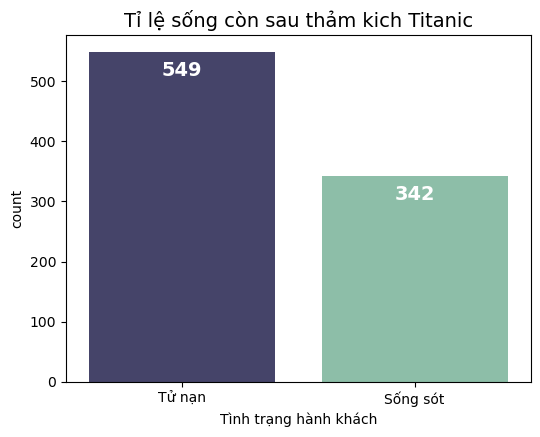

In [120]:
plt.figure(figsize=(6, 4.5)) 

ax = sns.countplot(x = 'Survived',hue='Survived', data = data, palette=["#3f3e6fd1", "#85c6a9"], legend=False)
plt.xticks( np.arange(2), ['Tử nạn', 'Sống sót'] )

plt.title("Tỉ lệ sống còn sau thảm kich Titanic",fontsize= 14)
plt.xlabel('Tình trạng hành khách')
labels = (data['Survived'].value_counts())
for i, v in enumerate(labels):
    ax.text(i, v-40, str(v), horizontalalignment = 'center', size = 14, color = 'w', fontweight = 'bold')
    
plt.show()

**Nhận xét**: Biến mục tiêu **Survived** có sự mất cân bằng nhẹ tuy nhiên không quá đáng kể dẫn đến sự thiên lệch về lớp chiếm đa số tuy nhiên vẫn phải lưu ý khi huấn luyện mô hình.

## 4. Trực quan hóa dữ liệu (Data Visualizations)

### 4.1 Biểu đồ đơn biến (Univariate Plots)

1. Hãy cùng xem xét trực quan hóa các thuộc tính riêng lẻ. Việc xem xét dữ liệu bằng nhiều hình ảnh trực quan khác nhau thường hữu ích để khơi gợi ý tưởng. Chúng ta hãy xem xét biểu đồ (histograms) của từng thuộc tính để nắm bắt được phân phối dữ liệu của chúng.

In [121]:
#Loại bỏ cột PassengerId do không liên quan đến việc dự đoán
numeric_data = data.select_dtypes(include=['int64', 'float64']).columns
numeric_data = numeric_data.drop('PassengerId', errors='ignore')

**Nhận xét**: Vì PassengerId không liên quan đến việc dự đoán nên ta có thể loại bỏ nó

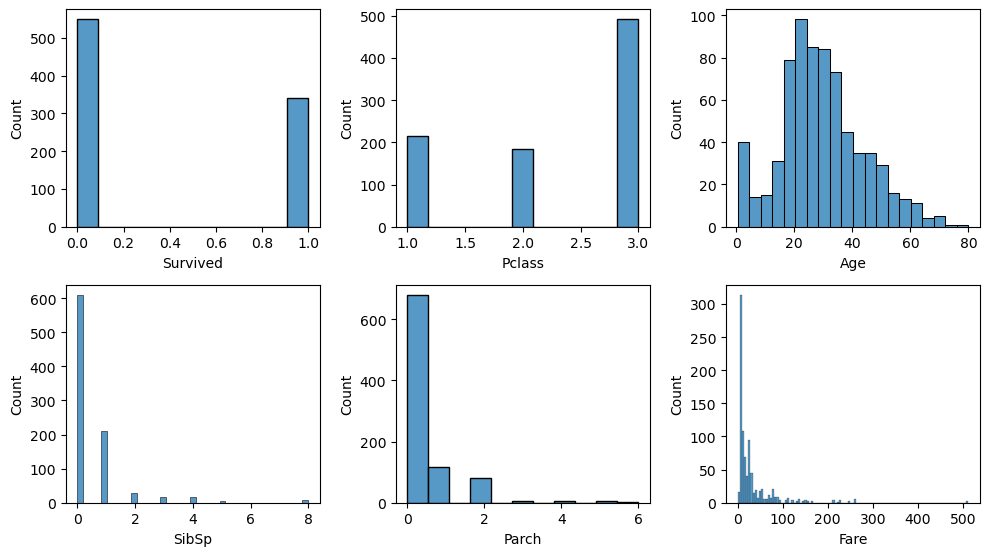

In [122]:
plt.figure(figsize=(10, 8))
for i, col in enumerate(numeric_data, 1):
    plt.subplot(3, 3, i )
    sns.histplot(data= data, x=col)
plt.tight_layout()
plt.show()

**Nhận xét**: 

+ Một số thuộc tính có thể có phân phối lệch phải (right-skewed distribution) chẳng hạn như **Fare, Age, SibSp và Parch** cho thấy phần lớn giá trị tập trung ở mức thấp và giảm dần về phía cao. 

+ Ngoài ra, **Pclass** có là dữ liệu dạng thứ bậc với tần suất cao nhất ở hạng 3, thể hiện phần lớn hành khách thuộc tầng lớp phổ thông. Hay **Survived** dạng phân loại với số người tử nạn chiểm phần lớn nên có thể thấy dữ liệu mục tiêu không cân bằng.


2. Hãy cùng xem xét các phân phối đó bằng cách sử dụng biểu đồ mật độ (density plots) giúp dễ nhận dạng hơn.

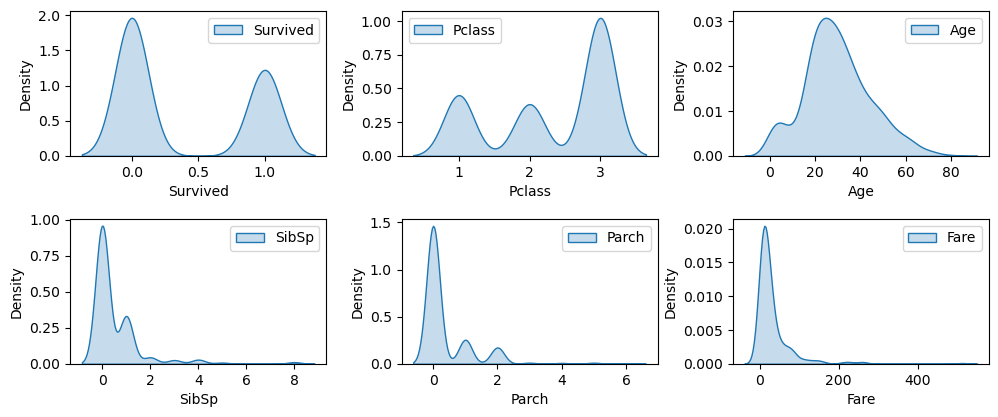

In [123]:
plt.figure(figsize=(10, 8))
for i, col in enumerate(numeric_data):
    plt.subplot(4, 3, i + 1)
    sns.kdeplot(data=data[col], label=col, fill=True)
    plt.xlabel(col)
    plt.legend()
plt.tight_layout()
plt.show()

**Nhận xét**: Điều này củng cố thêm bằng chứng cho sự nghi ngờ của chúng ta về khả năng tồn tại các phân phối lệch. Nó cũng có vẻ như **Age** có thể là một phân phối Gaussian bị lệch (hơi lệch phải) và **Fare, SibSp, Parch** rõ ràng là các phân phối lệch phải mạnh (tương tự phân phối mũ), điều này có thể hữu ích sau này với các phép biến đổi sau này.

3. Hãy cùng xem xét dữ bằng biểu đồ hộp và biểu đồ râu của từng thuộc tính. (Box and whisker)

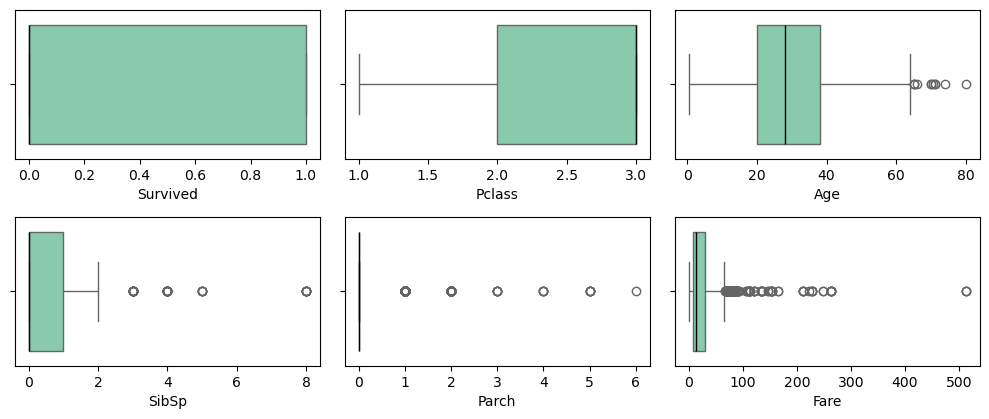

In [124]:
# Boxplot
plt.figure(figsize=(10, 8))

for i,col in enumerate(numeric_data):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(x=data[col], color="#7ED4AD",
                medianprops={"color": "black"})
    plt.xlabel(col)

plt.tight_layout()
plt.show()

**Nhận xét**: 
+ Dữ liệu có khá nhiều giá trị ngoại lai (outliers), đặc biệt ở các biến **Fare, SibSp, và Parch**.
+ Phần lớn các biến phân bố lệch phải (right-skewed) tức có nhiều giá trị nhỏ và một số ít giá trị lớn bất thường. Điều này gợi ý rằng các biến cần được chuẩn hóa hoặc xử lý ngoại lai trước khi đưa vào mô hình dự đoán.

### 4.2 Biểu đồ đa biến (Multivariate Plots)

1. Sử dụng heatmap để trực quan hóa ma trận tương quan, giúp phát hiện mối quan hệ tuyến tính giữa các biến. 

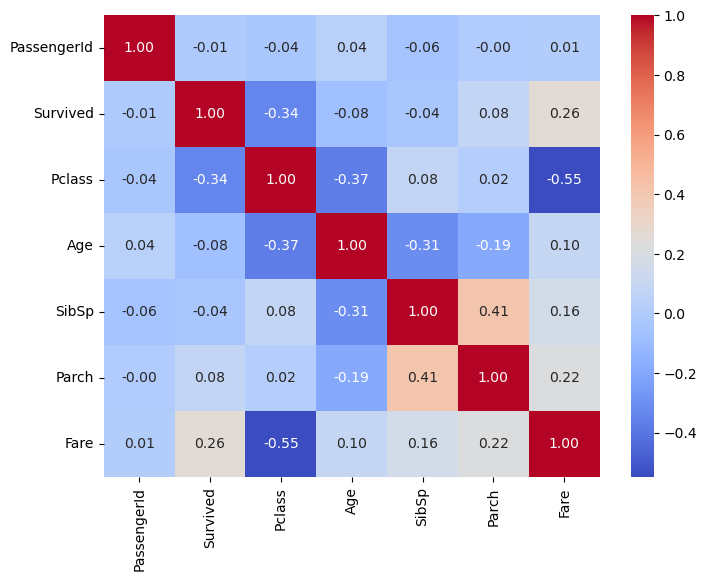

In [125]:
# Tính ma trận tương quan
numeric = data.select_dtypes(include=['int64', 'float64'])
corr = numeric.corr()

# Vẽ heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

**Nhận xét**: 
+ Các hệ số tương quan nằm trong khoảng -0.55 → 0.41, cho thấy không có mối tương quan tuyến tính mạnh tuyệt đối nào giữa các biến. Mối quan hệ chủ yếu ở mức yếu đến trung bình.
+ **Pclass và Fare** (-0.55) có mối tương quan cao nhất do việc hạng vé cao hay thấp phụ thuộc vào giá vé là hợp lí.
+  **SibSp và Parch** (0.41) có mối tương quan dương trung bình, cho thấy việc các hành khách có xu hướng đi cả gia đình.

2. Chúng ta sẽ thử xem sự liên quan các dữ liệu với Survived

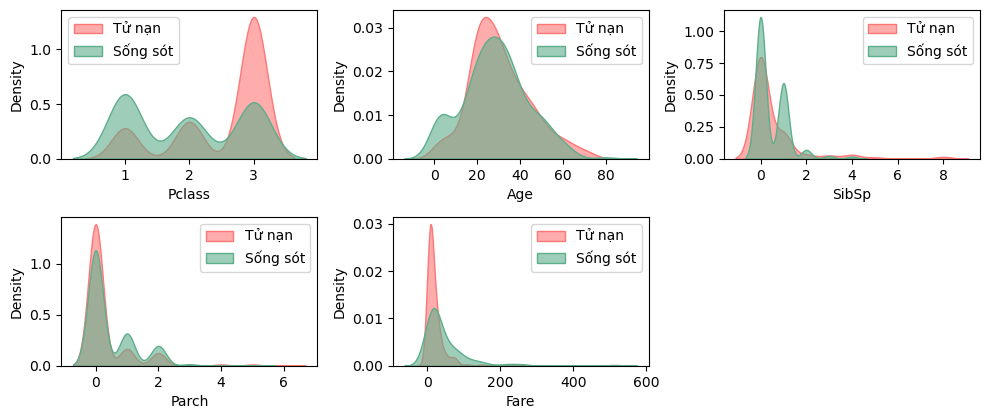

In [126]:
#Vì biểu đồ xem sự liên quan các dữ liệu với Survived nên cần loại bỏ ở hình vẽ này
numeric_cols = numeric_data.drop(['PassengerId', 'Survived'], errors='ignore')

plt.figure(figsize=(10, 8))
for i,col in enumerate(numeric_cols):
    plt.subplot(4, 3, i + 1)
    sns.kdeplot(data=data[data['Survived'] == 0], x=col, fill=True, label='Tử nạn', color='#FF7676', alpha=0.6)
    sns.kdeplot(data=data[data['Survived'] == 1], x=col, fill=True, label='Sống sót', color='#5DAE8B', alpha=0.6)
    plt.xlabel(col)
    plt.legend()
    
plt.tight_layout()
plt.show()

**Nhận xét**:
+ Ở đây ta có thể thấy rõ phần lớn hành khách hạng 3 (**Pclass** = 3) chủ yếu thuộc nhóm tử nạn. Ngược lại, hành khách hạng 1 có tỉ lệ sống sót cao hơn rõ rệt. 
+ Ở biến **Age** Đa số hành khách trong khoảng 20–40 tuổi, xu hướng trẻ em (tuổi nhỏ) có tỉ lệ sống sót nhỉnh hơn một chút nhưng nhìn chung phân phối giữa hai nhóm cũng khá tương đồng.
+ Có thể sử dụng ma trận tán xạ để xem rõ hơn về việc hạng vé (**Pclass**) hay độ tuổi (**Age**) có ảnh hưởng lớn hay không.

3. Để phân tích trực quan sự tương tác giữa các biến với Survived, ma trận tán xạ (scatter matrix) được sử dụng.

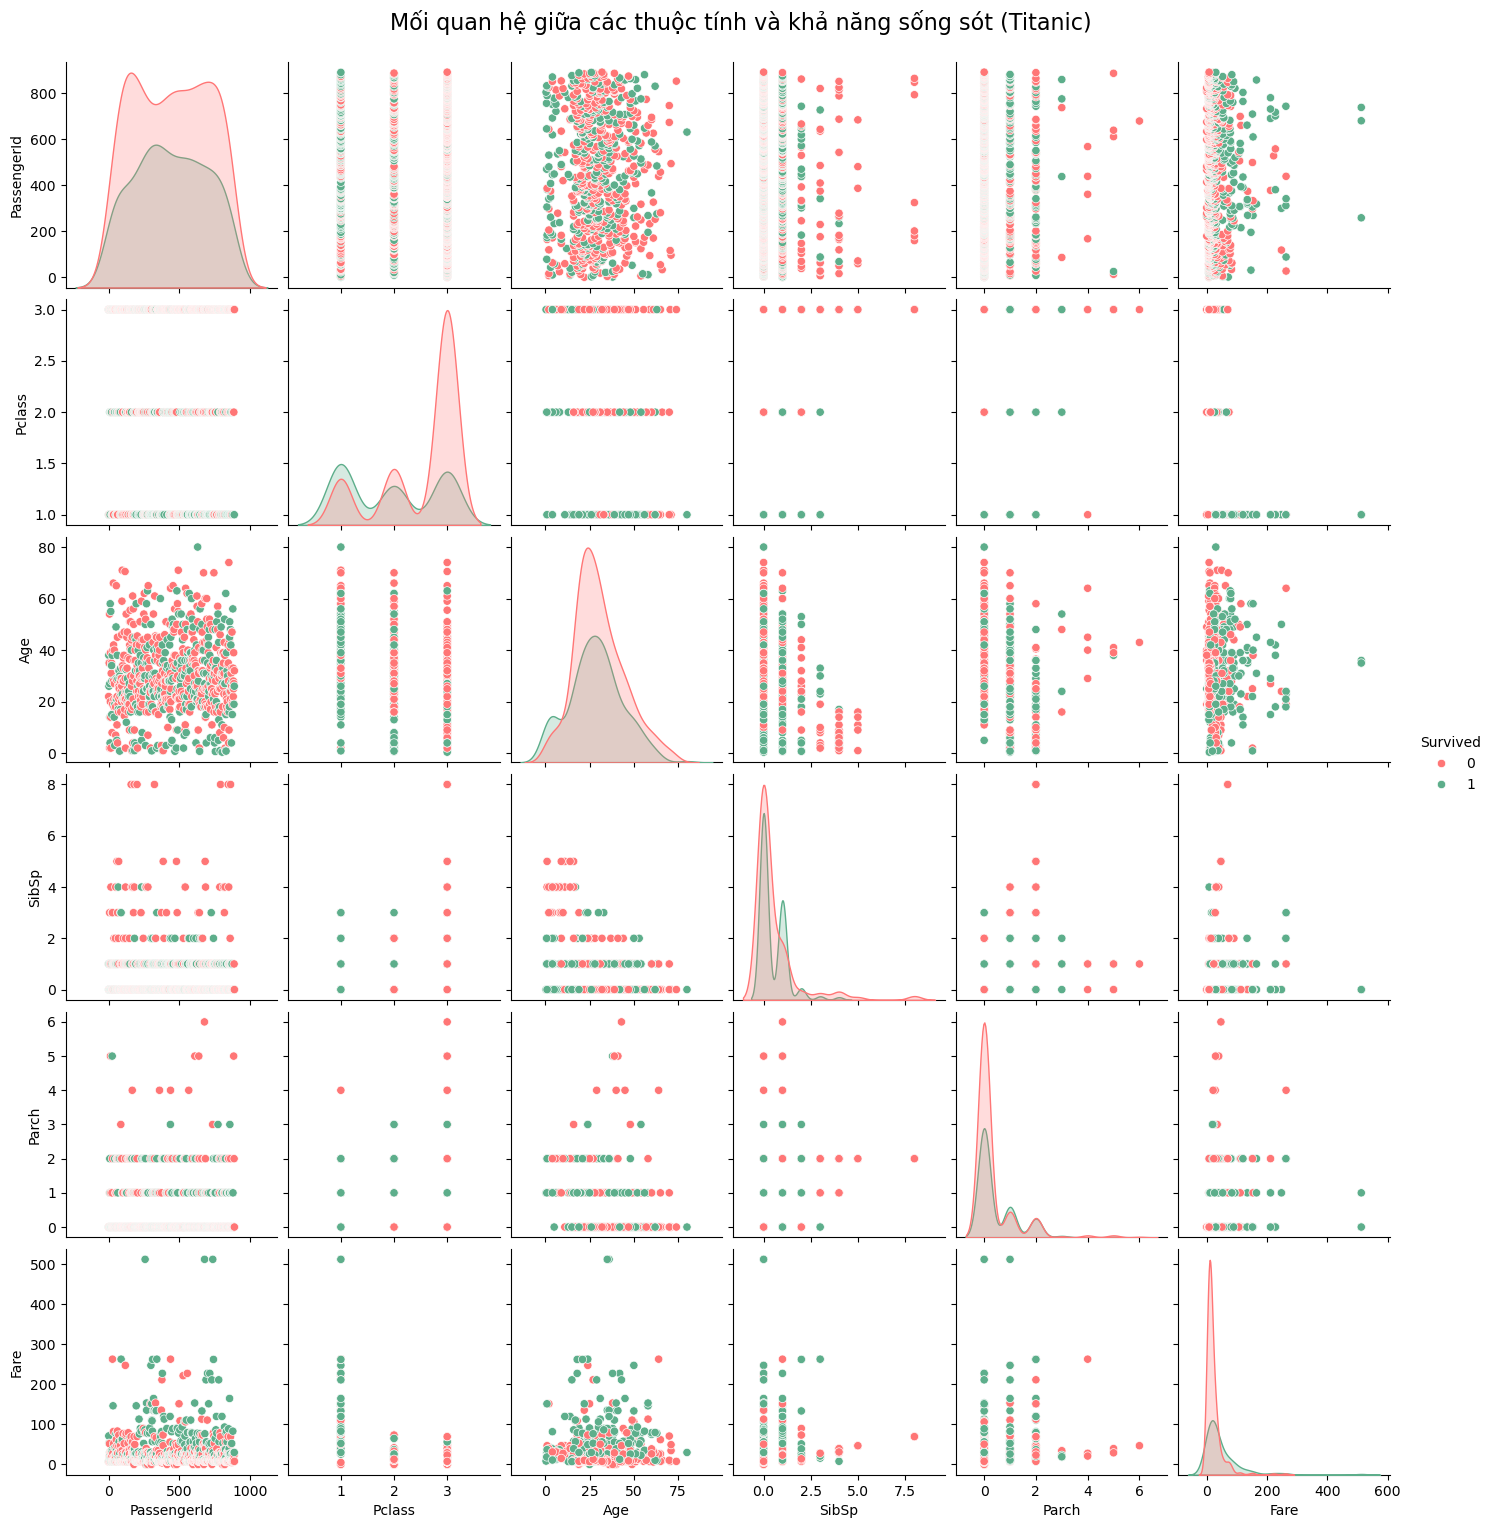

In [127]:
ax = sns.pairplot(
    numeric,
    hue="Survived",             
    diag_kind="kde",            
    kind="scatter",              
    palette=["#FF7676", "#5DAE8B"]
)

# Cấu hình hình ảnh
ax.fig.set_size_inches(15, 15)
ax.fig.suptitle('Mối quan hệ giữa các thuộc tính và khả năng sống sót (Titanic)', fontsize=16, y=1.02)

plt.show()

**Nhận xét**: 
+ Nhìn chung, hành khách sống sót có xu hướng đi vé hạng cao (số tử nạn ở vé hạng 3 có sự chênh lệch rõ rệt so với sống sót) hoặc có độ tuổi trẻ hơn so với nhóm tử nạn.
+ Hành khách đi một mình (SibSp, Parch = 0) thường không sống sót nhưng khi đi cùng gia đình hay anh chị em có tỉ lệ sống sót cao hơn đôi chút, có thể do đi cùng gia đình nên tỉ lệ hỗ trợ nhau cao hơn.
+ Biểu đồ tán xạ cho thấy có mối quan hệ yếu tuyến tính giữa các biến, nhưng các cụm dữ liệu lại thể hiện mối quan hệ phi tuyến rõ ràng (đặc biệt khi xác định theo **Survived**).

4. Sử dụng biểu đồ cột (bar chart) để xem mối quan hệ giữa các biến phân loại 

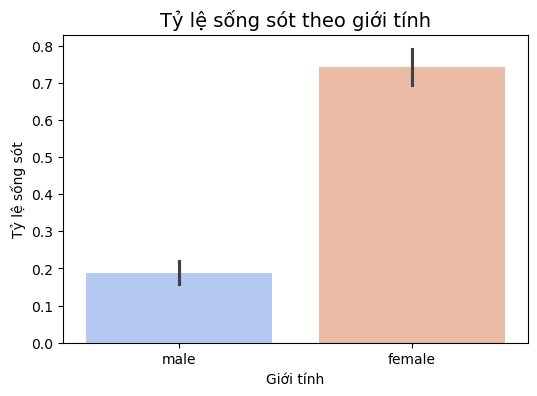

In [128]:
plt.figure(figsize=(6, 4))
sns.barplot(x='Sex', y='Survived', data=data, palette='coolwarm', estimator='mean',legend=False)
plt.title("Tỷ lệ sống sót theo giới tính", fontsize=14)
plt.ylabel("Tỷ lệ sống sót")
plt.xlabel("Giới tính")
plt.show()

**Nhận xét**: 
+ Nữ giới (female) có tỷ lệ sống sót rất cao, khoảng 74–75%, thể hiện qua cột màu cam cao vượt trội. Nam giới (male) có tỷ lệ sống sót rất thấp, chỉ khoảng 19–20%, thấp hơn nữ gần 4 lần.

+ Điều này phản ánh rõ quy tắc “Phụ nữ và trẻ em được ưu tiên lên thuyền cứu hộ trước” trong thảm họa Titanic. Ngoài ra, nam giới thường nhường chỗ hoặc tham gia hỗ trợ sơ tán, dẫn đến tỷ lệ sống sót thấp hơn.

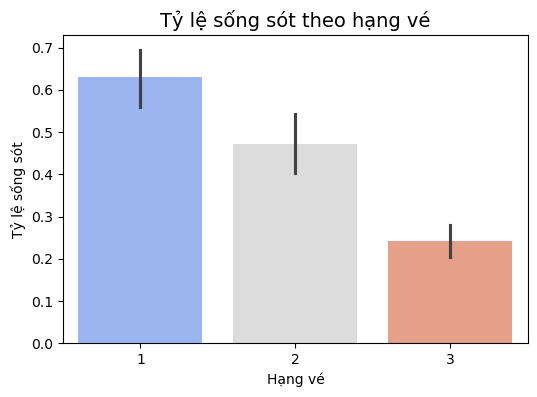

In [129]:
plt.figure(figsize=(6, 4))
sns.barplot(x='Pclass', y='Survived', data=data, palette='coolwarm', estimator='mean')
plt.title("Tỷ lệ sống sót theo hạng vé", fontsize=14)
plt.ylabel("Tỷ lệ sống sót")
plt.xlabel("Hạng vé")
plt.show()

In [130]:
data['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

**Nhận xét**: Biểu đồ này càng khẳng định việc hạng vé càng cao (1>2>3) thì tỉ lệ sống sót càng cao. Do các khoang hạng nhất thường được trang bị những đồ cần thiết cho trường hợp xấu nhất xảy ra và ít hành khách ở khoang này nên việc chen lấn không có hay tranh thiết bị gần như đủ cho mọi người ở khoang này.